In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.offline as pyo
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
warnings.filterwarnings('ignore')

sys.path.append('../src') 

from data_loader import load_gdp
from preprocessing import apply_double_median_filter, detect_outliers_mad, remove_outliers_by_trend
from evaluation import adf_test_summary, kpss_test_summary
from models_arima import arima_parameters, train_arima
from models_rf import create_lagged_features, train_rf_model, walk_forward_forecast_rf, get_feature_importance

## Загрузка данных о ВВП(1970-2024) из FRED 

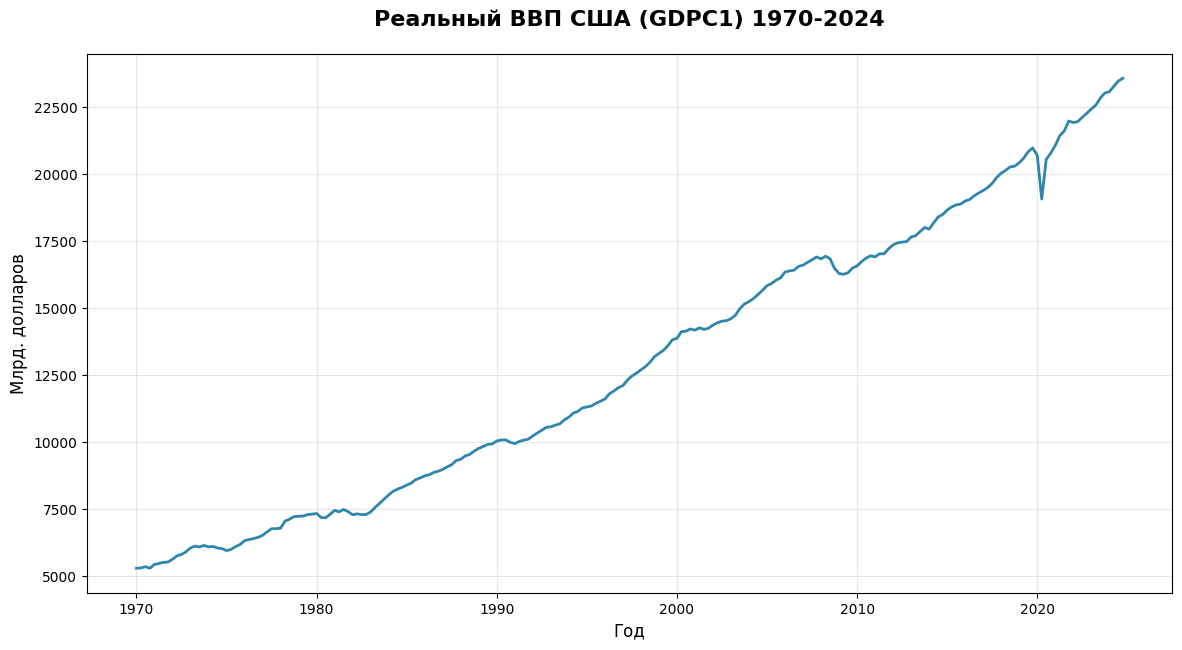

In [2]:
gdp_raw_series = load_gdp()

plt.figure(figsize=(14, 7))
plt.plot(gdp_raw_series.index, gdp_raw_series.values, linewidth=2, color='#2E86AB')
plt.title('Реальный ВВП США (GDPC1) 1970-2024', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Млрд. долларов', fontsize=12)
plt.xlabel('Год', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## Анализ статистических показателей и пропусков ВВП

In [3]:
print(f"Период анализа: {gdp_raw_series.index[0].strftime('%Y')}-{gdp_raw_series.index[-1].strftime('%Y')}")
print(f"Количество наблюдений: {len(gdp_raw_series)}")
print("\nОсновные показатели (в млрд. долл. 2017 года):")
print(f"• Среднее значение: {gdp_raw_series.mean():.0f}")
print(f"• Стандартное отклонение: {gdp_raw_series.std():.0f}")
print(f"• Минимальное значение: {gdp_raw_series.min():.0f} ({gdp_raw_series.idxmin().strftime('%Y-%m')})")
print(f"• Максимальное значение: {gdp_raw_series.max():.0f} ({gdp_raw_series.idxmax().strftime('%Y-%m')})")
print()
print(f"Пропущенные значения: {gdp_raw_series.isnull().sum()}")
print(f"Доля пропусков: {gdp_raw_series.isnull().mean() * 100:.2f}%")

Период анализа: 1970-2024
Количество наблюдений: 220

Основные показатели (в млрд. долл. 2017 года):
• Среднее значение: 12938
• Стандартное отклонение: 5298
• Минимальное значение: 5300 (1970-10)
• Максимальное значение: 23587 (2024-10)

Пропущенные значения: 0
Доля пропусков: 0.00%


## Анализ структуры и выбросов ВВП

In [4]:
gdp_trend_estimate, gdp_trend_residuals =  apply_double_median_filter(gdp_raw_series, window1=5, window2=3)

gdp_outlier_mask, mad_gdp, sigma_hat_gdp = detect_outliers_mad(gdp_trend_residuals, k=5.2)

outliers = pd.DataFrame({
        'value': gdp_raw_series[gdp_outlier_mask],
        'trend_estimate': gdp_trend_estimate[gdp_outlier_mask],
        'residual': gdp_trend_residuals[gdp_outlier_mask],
    })
print("Найденные выбросы (по критерию |r| > 5.2 * 1.4826*MAD):")
print(outliers)
print()
print(f"Найдено выбросов (по scaled-MAD): {gdp_outlier_mask.sum()}")
print(f"MAD остатков: {mad_gdp:.2f}")
print(f"Оценка sigma (1.4826*MAD): {sigma_hat_gdp:.2f}")

Найденные выбросы (по критерию |r| > 5.2 * 1.4826*MAD):
                value  trend_estimate    residual
1980-07-01   7181.743      7315.67700  -133.93400
2019-07-01  20843.322     20682.47775   160.84425
2019-10-01  20985.448     20709.21200   276.23600
2020-04-01  19077.992     20709.21200 -1631.22000
2020-07-01  20558.879     20729.88825  -171.00925
2021-10-01  21988.737     21862.57325   126.16375
2024-10-01  23586.542     23430.55450   155.98750

Найдено выбросов (по scaled-MAD): 7
MAD остатков: 16.16
Оценка sigma (1.4826*MAD): 23.96


Обнаруженные выбросы соответствуют кризисным периодам и заменены оценкой тренда для сохранения структуры ряда без искажения динамики

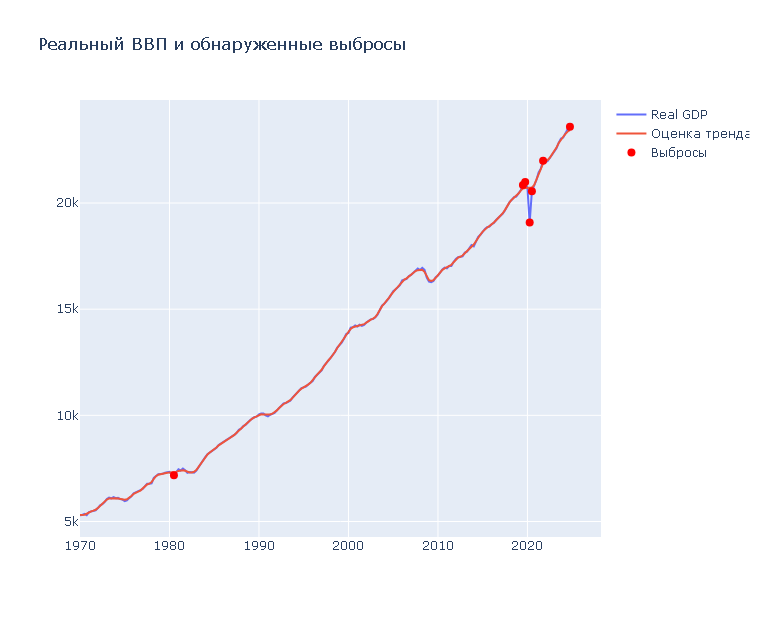

In [5]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=gdp_raw_series.index,
    y=gdp_raw_series.values,
    mode='lines',
    name='Real GDP'
))

fig.add_trace(go.Scatter(
    x=gdp_trend_estimate.index,
    y=gdp_trend_estimate.values,
    mode='lines',
    name='Оценка тренда'
))

fig.add_trace(go.Scatter(
    x=gdp_raw_series.index[gdp_outlier_mask],
    y=gdp_raw_series.values[gdp_outlier_mask],
    mode='markers',
    marker=dict(size=8, color='red'),
    name='Выбросы'
))

fig.update_layout(
    title='Реальный ВВП и обнаруженные выбросы',
    width=1100,
    height=600,
    hovermode='x unified'
)

pyo.iplot(fig)

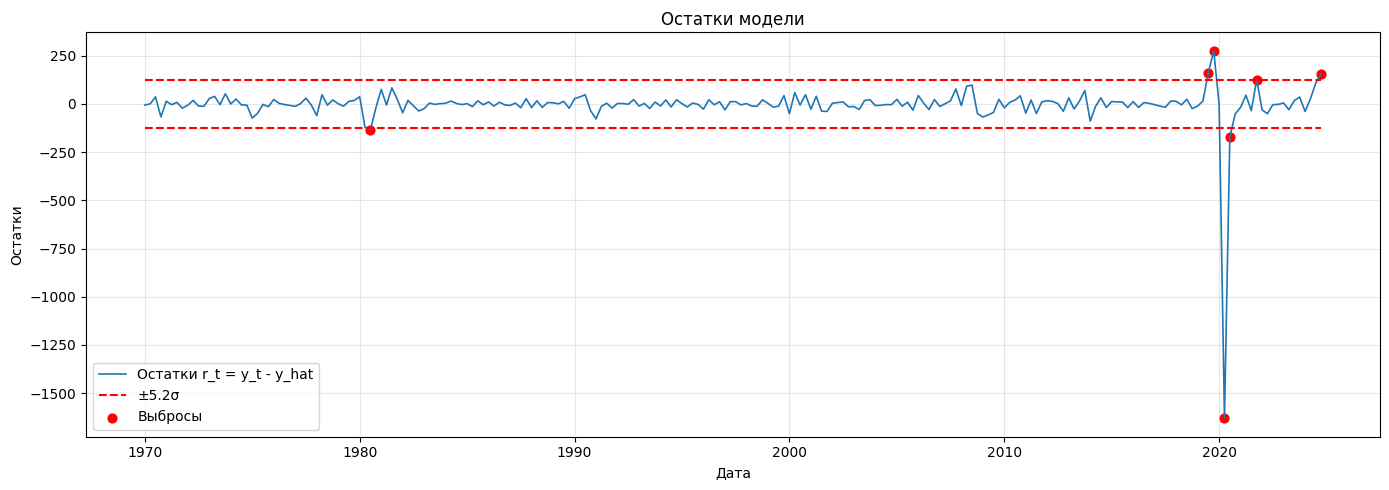

In [6]:
threshold = 5.2 * sigma_hat_gdp
plt.figure(figsize=(14,5))
plt.title("Остатки модели")
plt.plot(gdp_trend_residuals.index, gdp_trend_residuals.values, label='Остатки r_t = y_t - y_hat', linewidth=1.2)
plt.hlines(threshold, gdp_trend_residuals.index[0], gdp_trend_residuals.index[-1], colors='red', linestyles='--', label='±5.2σ')
plt.hlines(-threshold, gdp_trend_residuals.index[0], gdp_trend_residuals.index[-1], colors='red', linestyles='--')
plt.scatter(gdp_trend_residuals.index[gdp_outlier_mask], gdp_trend_residuals.values[gdp_outlier_mask], color='red', s=40, label='Выбросы')
plt.xlabel('Дата')
plt.ylabel('Остатки')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
gdp_clean_series = remove_outliers_by_trend(gdp_raw_series, gdp_trend_estimate, gdp_outlier_mask)

## Проверка стационарности исходного ряда ВВП

In [8]:
adf_result = adf_test_summary(gdp_clean_series)

Результаты теста Дики-Фуллера:
ADF Statistic: 1.899016
p-value: 0.998526
Количество наблюдений: 217
Критические значения:
   1%: -3.461
   5%: -2.875
   10%: -2.574


Ряд НЕСТАЦИОНАРЕН (не отвергаем H0)

In [9]:
kpss_result = kpss_test_summary(gdp_clean_series)

Результаты теста KPSS:
KPSS Statistic: 0.376369
p-value: 0.010000
Количество наблюдений: 220
Критические значения:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


Ряд НЕСТАЦИОНАРЕН (отвергаем H0)

## Формирование обучающей и тестовой выборок

Разбиение выполнено по времени для предотвращения утечки информации

In [10]:
gdp_train = gdp_clean_series.loc['1970-01-01':'2009-12-31']
gdp_test = gdp_clean_series.loc['2010-01-01':'2024-12-31']

gdp_train_log = np.log(gdp_train)
gdp_train_log_diff = gdp_train_log.diff().dropna()

print("Train size:", len(gdp_train))
print("Test size:", len(gdp_test))

Train size: 160
Test size: 60


## Проверка стационарности преобразованного ряда ВВП

In [11]:
adf_res_log_diff = adf_test_summary(gdp_train_log_diff)

Результаты теста Дики-Фуллера:
ADF Statistic: -4.381968
p-value: 0.000319
Количество наблюдений: 147
Критические значения:
   1%: -3.476
   5%: -2.881
   10%: -2.577


Ряд СТАЦИОНАРЕН (отвергаем H0)

In [12]:
kpss_res_log_diff = kpss_test_summary(gdp_train_log_diff)

Результаты теста KPSS:
KPSS Statistic: 0.069909
p-value: 0.100000
Количество наблюдений: 159
Критические значения:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


Ряд СТАЦИОНАРЕН (не отвергаем H0)

# ARIMA

## Параметры Arima

Параметры ARIMA подбираются по критерию AIC на лог-разностном стационарном ряде один раз и далее фиксировались для walk-forward прогнозирования.

In [13]:
arima_order = arima_parameters(gdp_train_log_diff)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1060.285, Time=0.11 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-977.026, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1035.318, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1005.490, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1059.396, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-1061.481, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1061.061, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-1063.029, Time=0.04 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-1061.288, Time=0.03 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-1059.142, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-1078.567, Time=0.05 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-1068.253, Time=0.02 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-1077.312, Time=0.12 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-1077.360, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)

## Построение прогноза

Реализация прогнозирования выполнена в режиме пошагового (walk-forward) прогнозирования с расширяющимся окном(expanding window): для каждой точки из тестовой выборки модель обучалась на всех доступных на тот момент наблюдениях, делался одномоментный прогноз на следующий квартал, а затем прогнозы обратно превращались в уровень ВВП посредством обратного преобразования (суммирование прогнозного приращения к последнему логарифму и экспоненцирование)

In [14]:
arima_result = train_arima(gdp_clean_series, gdp_test, arima_order)

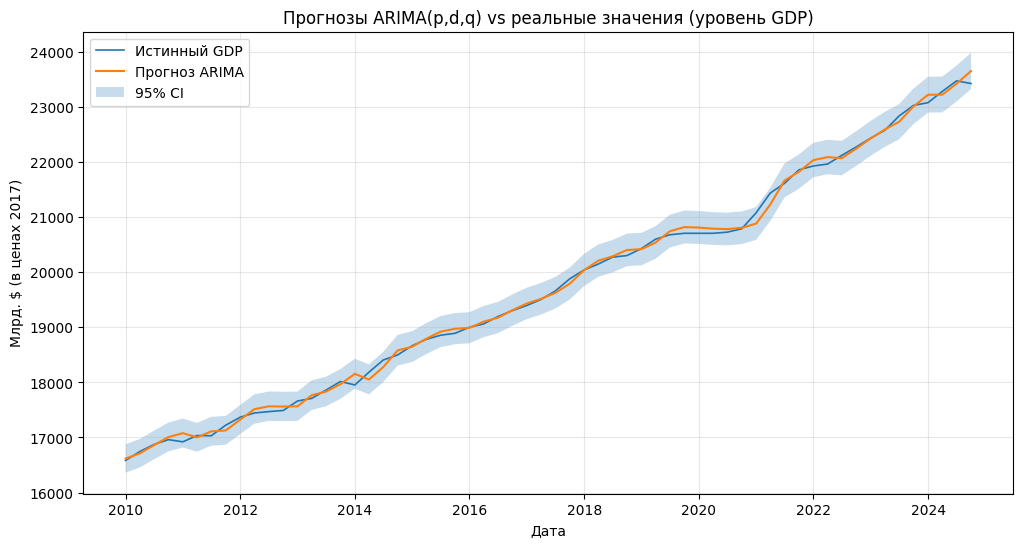

In [15]:
plt.figure(figsize=(12,6))
plt.plot(gdp_clean_series.loc[arima_result.index[0]:arima_result.index[-1]], label='Истинный GDP', linewidth=1.2)
plt.plot(arima_result['forecast_arima'], label='Прогноз ARIMA', linewidth=1.5)
plt.fill_between(arima_result.index, arima_result['lower_ci'], arima_result['upper_ci'], alpha=0.25, label='95% CI')
plt.title('Прогнозы ARIMA(p,d,q) vs реальные значения (уровень GDP)')
plt.legend()
plt.ylabel('Млрд. $ (в ценах 2017)')
plt.xlabel('Дата')
plt.grid(alpha=0.3)
plt.show()

## Анализ остатков 

Анализ остатков необходим для проверки адекватности модели и выявления остаточной автокорреляции.

In [16]:
arima_residuals = arima_result["residual"]

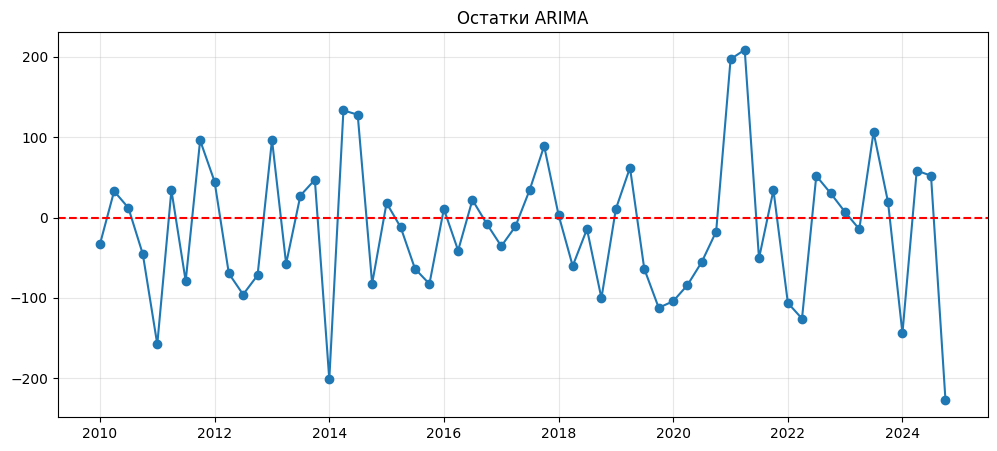

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(arima_residuals, marker='o')
plt.axhline(0, color='red', linestyle='--')
plt.grid(alpha=0.3)
plt.title("Остатки ARIMA")
plt.show()

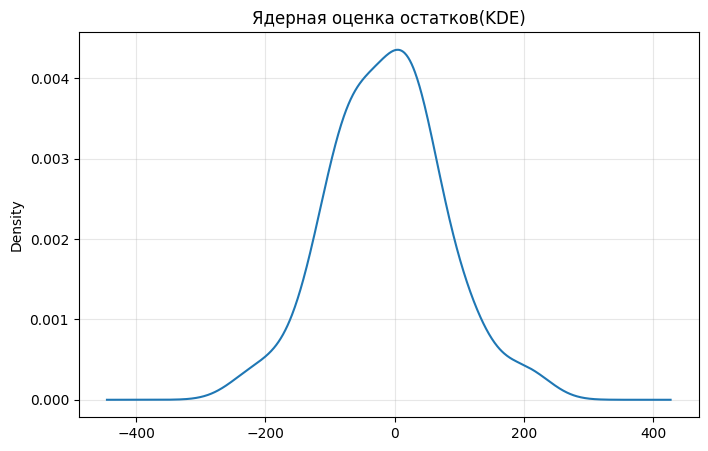

In [18]:
plt.figure(figsize=(8, 5))
arima_residuals.plot(kind='kde')
plt.grid(alpha=0.3)
plt.title("Ядерная оценка остатков(KDE)")
plt.show()

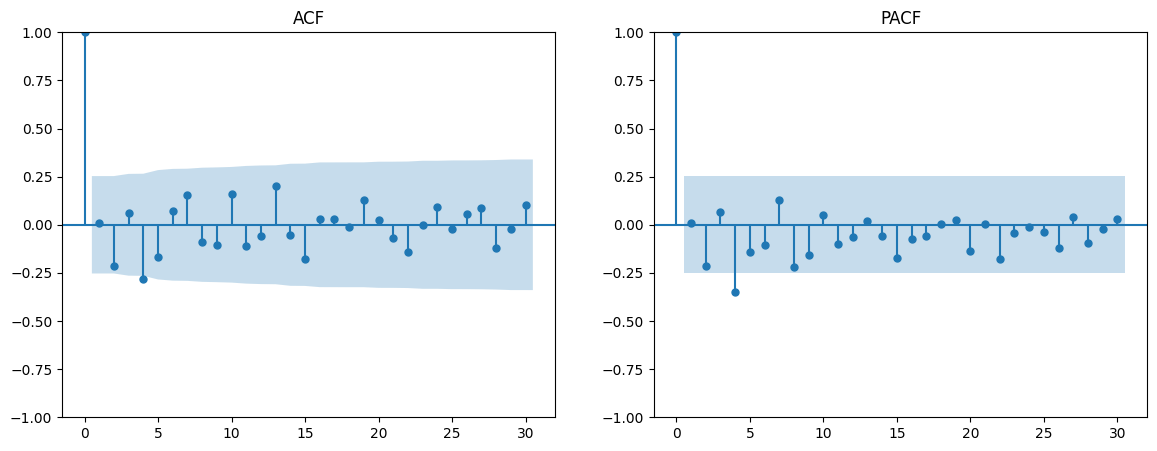

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(arima_residuals, ax=ax[0], lags=30)
ax[0].set_title("ACF")

plot_pacf(arima_residuals, ax=ax[1], lags=30, method="ywm")
ax[1].set_title("PACF")
plt.show()

In [20]:
lb = acorr_ljungbox(arima_residuals, lags=[30], return_df=True)
print("ТЕСТ LJUNG–BOX:")
print(lb)

ТЕСТ LJUNG–BOX:
      lb_stat  lb_pvalue
30  32.198561   0.358351


Остатки НЕ коррелированы (p > 0.05). Похоже на белый шум.

In [21]:
arima_residuals_mean = arima_residuals.mean()
print("Среднее значение остатков:", arima_residuals_mean)

Среднее значение остатков: -12.738226533544548


Остатки модели ведут себя как белый шум (несмещённые, некоррелированные случайные колебания)

# Random Forest

## Настройка

In [22]:
lags = 8

param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

## Подбор гиперпараметров

In [23]:
X_rf, y_rf = create_lagged_features(gdp_train_log_diff, lags)

best_rf_model, best_rf_parameters = train_rf_model(X_rf, y_rf, param_grid_rf)
print("Лучшие параметры RF:", best_rf_parameters)

Лучшие параметры RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}


## Построение прогноза

Модель обучается в режиме expanding window (walk-forward), как и ARIMA: для каждой тестовой даты модель переобучается на всех доступных до неё наблюдениях, затем производится одномоментный прогноз разницы логарифма и обратное преобразование к уровню ВВП

In [24]:
rf_result = walk_forward_forecast_rf(gdp_clean_series, gdp_test, lags, best_rf_parameters)

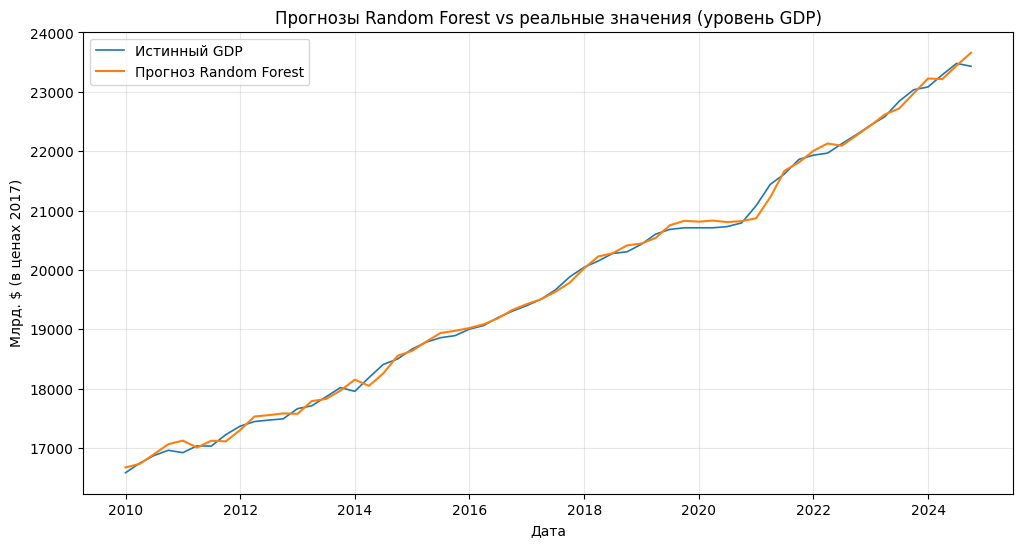

In [25]:
plt.figure(figsize=(12,6))
plt.plot(gdp_clean_series.loc[rf_result.index[0]:rf_result.index[-1]], label='Истинный GDP', linewidth=1.2)
plt.plot(rf_result['forecast'], label='Прогноз Random Forest', linewidth=1.5)
plt.title('Прогнозы Random Forest vs реальные значения (уровень GDP)')
plt.legend()
plt.ylabel('Млрд. $ (в ценах 2017)')
plt.xlabel('Дата')
plt.grid(alpha=0.3)
plt.show()

## Анализ важности признаков

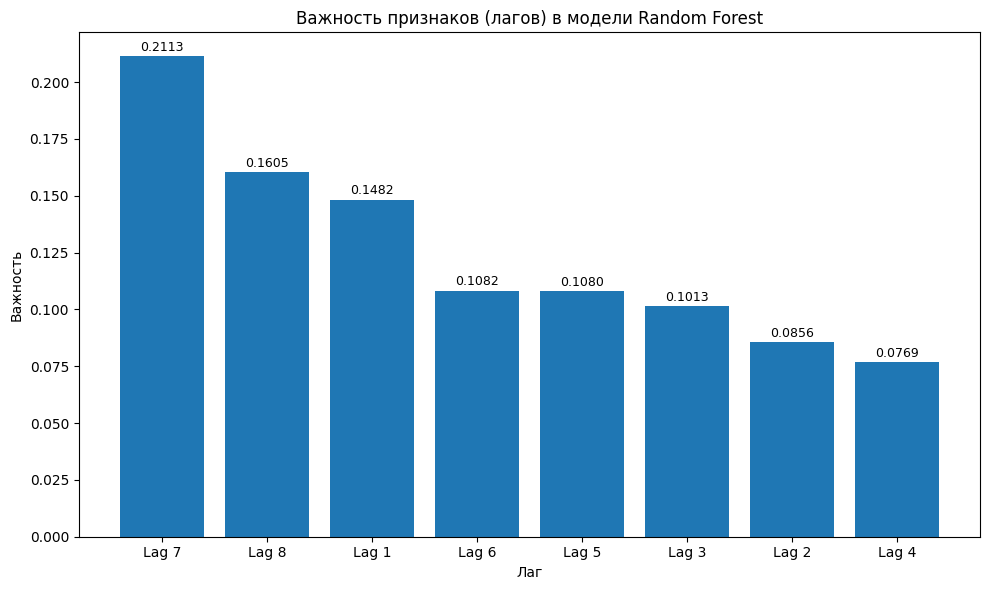

In [27]:
rf_importance = get_feature_importance(best_rf_model, lags)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(rf_importance)), rf_importance['importance'], align='center')
plt.xticks(range(len(rf_importance)), rf_importance['feature'])
plt.xlabel('Лаг')
plt.ylabel('Важность')
plt.title('Важность признаков (лагов) в модели Random Forest')

for bar, importance in zip(bars, rf_importance['importance']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{importance:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()